In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier #Clasificación multiclase
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine

In [4]:
wine= load_wine() #cargamos el dataset
x= wine.data #obtenemos los datos (x)
y= wine.target #obtenemos las etiquetas (y)

In [5]:
print(x.shape) #obtenemos la forma de x (2D)
print(x) 

(178, 13)
[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]


In [6]:
print(y.shape) #forma de y (1D)
print(y)

(178,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [8]:
#---ANÁLISIS EXPLORATORIO DEL DATASET---
frame = pd.DataFrame(x,y,columns= wine.feature_names) #CREAMOS EL DATAFRAME CON PANDAS
frame['etiqueta']= wine.target #AGREGAMOS UNA COLUMNA NUEVA CON LAS ETIQUETAS REALES
frame['nombre_etiqueta']= wine.target_names[wine.target] #AGREGAMOS UNA COLUMNA CON LOS NOMBRES DE ETIQUETA
print(frame[frame['etiqueta']==1]) #EJEM. DE FILTRO CON PANDAS ()
#print(frame) #MOSTRAMOS TODA LA DATA

    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
1     12.37        0.94  1.36               10.6       88.0           1.98   
1     12.33        1.10  2.28               16.0      101.0           2.05   
1     12.64        1.36  2.02               16.8      100.0           2.02   
1     13.67        1.25  1.92               18.0       94.0           2.10   
1     12.37        1.13  2.16               19.0       87.0           3.50   
..      ...         ...   ...                ...        ...            ...   
1     12.07        2.16  2.17               21.0       85.0           2.60   
1     12.43        1.53  2.29               21.5       86.0           2.74   
1     11.79        2.13  2.78               28.5       92.0           2.13   
1     12.37        1.63  2.30               24.5       88.0           2.22   
1     12.04        4.30  2.38               22.0       80.0           2.10   

    flavanoids  nonflavanoid_phenols  proanthocyanins  color_in

In [11]:
print(frame.head(5))

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
0    13.20        1.78  2.14               11.2      100.0           2.65   
0    13.16        2.36  2.67               18.6      101.0           2.80   
0    14.37        1.95  2.50               16.8      113.0           3.85   
0    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
0        2.76                  0.26             1.28             4.38  1.05   
0        3.24                  0.30             2.81             5.68  1.03   
0        3.49                  0.24             2.18             7.80  0.86   
0        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  etiqueta nombre_etiq

In [12]:
#DIVIDIMOS EL DATASET EN 2 PARTES: ENTRENAMIENTO (80%) Y PRUEBA (20%)
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state= 42)

In [13]:
#CREACIÓN Y ENTRENAMIENTO DEL MODELO (ÁRBOL DE DECISIONES PARA CLASIFICACIÓN MULTICLASE)
model= DecisionTreeClassifier()
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [14]:
print(x_test)
print(y_test)

[[1.364000e+01 3.100000e+00 2.560000e+00 1.520000e+01 1.160000e+02
  2.700000e+00 3.030000e+00 1.700000e-01 1.660000e+00 5.100000e+00
  9.600000e-01 3.360000e+00 8.450000e+02]
 [1.421000e+01 4.040000e+00 2.440000e+00 1.890000e+01 1.110000e+02
  2.850000e+00 2.650000e+00 3.000000e-01 1.250000e+00 5.240000e+00
  8.700000e-01 3.330000e+00 1.080000e+03]
 [1.293000e+01 2.810000e+00 2.700000e+00 2.100000e+01 9.600000e+01
  1.540000e+00 5.000000e-01 5.300000e-01 7.500000e-01 4.600000e+00
  7.700000e-01 2.310000e+00 6.000000e+02]
 [1.373000e+01 1.500000e+00 2.700000e+00 2.250000e+01 1.010000e+02
  3.000000e+00 3.250000e+00 2.900000e-01 2.380000e+00 5.700000e+00
  1.190000e+00 2.710000e+00 1.285000e+03]
 [1.237000e+01 1.170000e+00 1.920000e+00 1.960000e+01 7.800000e+01
  2.110000e+00 2.000000e+00 2.700000e-01 1.040000e+00 4.680000e+00
  1.120000e+00 3.480000e+00 5.100000e+02]
 [1.430000e+01 1.920000e+00 2.720000e+00 2.000000e+01 1.200000e+02
  2.800000e+00 3.140000e+00 3.300000e-01 1.970000e+00

In [ ]:

#PREDICCIÓN INDIVIDUAL 1
print('Predicción individual 1')
muestra_prueba= np.array([[1.364000e+01, 3.100000e+00, 2.560000e+00, 1.520000e+01, 1.160000e+02,
  2.700000e+00 ,3.030000e+00, 1.700000e-01 ,1.660000e+00, 5.100000e+00,
  9.600000e-01, 3.360000e+00 ,8.450000e+02]]) #EXTRAEMOS UNA MUESTRA INDIVIDUAL
prediccion= model.predict(muestra_prueba) #OBTENEMOS LA ETIQUETA REAL DE LA PREDICCIÓN
print(prediccion)
print(wine.target_names[prediccion]) #OBTENEMOS EL NOMBRE DE LA ETIQUETA OBTENIDA

Predicción individual
[0]
['class_0']


In [16]:
#PREDICCIÒN INDIVIDUAL 2
muestra_prueba = x_test[1].reshape(1,-1) #selecciòn de una mmuestra de x_test
print("Predicciòn Individual 1")
print("Muestra seleccionada")
print(muestra_prueba)
prediccion = model.predict(muestra_prueba)
print("predicciòn del modelo")
print(prediccion)
print("etiqueta real")
print(y_test[1])

Predicciòn Individual 1
Muestra seleccionada
[[1.421e+01 4.040e+00 2.440e+00 1.890e+01 1.110e+02 2.850e+00 2.650e+00
  3.000e-01 1.250e+00 5.240e+00 8.700e-01 3.330e+00 1.080e+03]]
predicciòn del modelo
[0]
etiqueta real
0


In [22]:
#PREDICCIÒN TOTAL
print("Predicciòn con toda la data de prueba")
print(model.predict(x_test))
print("Etiquetas reales de la data de pruebas")
print(y_test)


Predicciòn con toda la data de prueba
[0 0 2 0 1 0 1 2 1 2 1 0 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]
Etiquetas reales de la data de pruebas
[0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]


Gràfica de certidumbre de predicciones


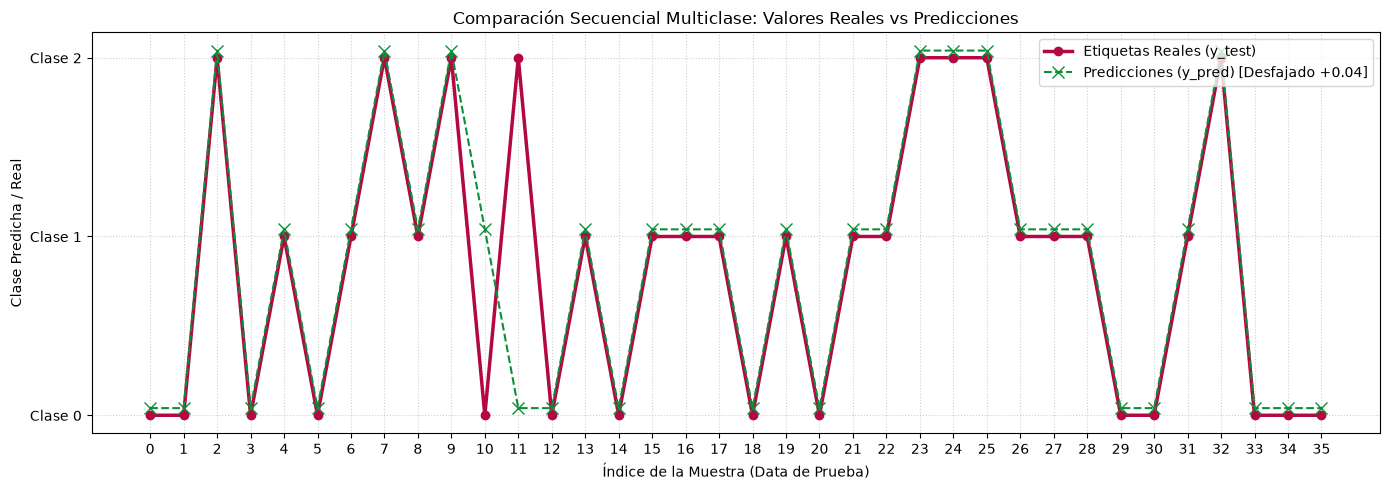

In [24]:
print("Gràfica de certidumbre de predicciones")
y_pred = model.predict(x_test)
import matplotlib.pyplot as plt
import numpy as np

# Creamos el índice para el eje X (de 0 a 35)
muestras = np.arange(len(y_test))

plt.figure(figsize=(14, 5))

# Graficamos la línea real (continua y más gruesa)
plt.plot(muestras, y_test, color="#b30841", linestyle='-', linewidth=2.5, label='Etiquetas Reales (y_test)', marker='o', markersize=6)

# Graficamos la línea de predicción (discontinua, más delgada y con un JITTER/desfase mínimo de 0.05 para que veas el calce)
plt.plot(muestras, y_pred + 0.04, color="#0c8f38", linestyle='--', linewidth=1.5, label='Predicciones (y_pred) [Desfajado +0.04]', marker='x', markersize=8)

# Configuración estética para datos multiclase discretos
plt.yticks([0, 1, 2], ['Clase 0', 'Clase 1', 'Clase 2'])
plt.xticks(muestras) # Muestra el número de cada muestra en el eje X
plt.xlabel('Índice de la Muestra (Data de Prueba)')
plt.ylabel('Clase Predicha / Real')
plt.title('Comparación Secuencial Multiclase: Valores Reales vs Predicciones')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Ajustar diseño para que no se corten las etiquetas
plt.tight_layout()
plt.show()
